In [1]:
import torch
import pandas as pd

from pathlib import Path
from PIL import Image

from torchvision import transforms

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0+cpu


In [2]:
PROJECT_ROOT = Path.cwd()

# In case the notebook kernel starts inside the notebooks folder
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

IMAGE_DIR = PROJECT_ROOT / "data" / "raw" / "images"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Image directory:", IMAGE_DIR)
print("Processed directory:", PROCESSED_DIR)

Project root: d:\ML-Projects\skin-cancer-detection
Image directory: d:\ML-Projects\skin-cancer-detection\data\raw\images
Processed directory: d:\ML-Projects\skin-cancer-detection\data\processed


In [3]:
train_df = pd.read_csv(
    PROCESSED_DIR / "train.csv"
)

val_df = pd.read_csv(
    PROCESSED_DIR / "validation.csv"
)

test_df = pd.read_csv(
    PROCESSED_DIR / "test.csv"
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 8011
Validation images: 1002
Test images: 1002


In [4]:
train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,diagnosis_name,split,dataset_split
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratinocytic lesions,8,train
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratinocytic lesions,8,train
2,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,Benign keratinocytic lesions,5,train
3,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,Benign keratinocytic lesions,5,train
4,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,vidir_modern,Benign keratinocytic lesions,2,train


In [5]:
CLASS_NAMES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: class_name
    for class_name, index in CLASS_TO_INDEX.items()
}

print(CLASS_TO_INDEX)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [6]:
from torch.utils.data import Dataset


class SkinLesionDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_id = row["image_id"]
        label_name = row["dx"]

        image_path = self.image_dir / f"{image_id}.jpg"

        image = Image.open(image_path).convert("RGB")

        label = CLASS_TO_INDEX[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label
    

In [7]:
basic_transform = transforms.ToTensor()

In [8]:
train_dataset = SkinLesionDataset(
    dataframe=train_df,
    image_dir=IMAGE_DIR,
    transform=basic_transform
)

print("Dataset size:", len(train_dataset))

Dataset size: 8011


In [9]:
image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label)
print("Label name:", INDEX_TO_CLASS[label])
print("Tensor dtype:", image.dtype)

Image tensor shape: torch.Size([3, 450, 600])
Label: 2
Label name: bkl
Tensor dtype: torch.float32


In [10]:
import matplotlib.pyplot as plt

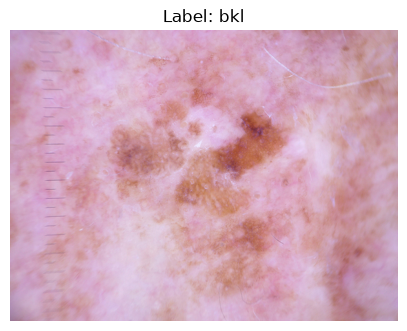

In [11]:
plt.figure(figsize=(5, 5))

plt.imshow(image.permute(1, 2, 0))

plt.title(f"Label: {INDEX_TO_CLASS[label]}")
plt.axis("off")

plt.show()

In [12]:
from torch.utils.data import DataLoader


In [13]:
val_dataset = SkinLesionDataset(
    dataframe=val_df,
    image_dir=IMAGE_DIR,
    transform=basic_transform
)

test_dataset = SkinLesionDataset(
    dataframe=test_df,
    image_dir=IMAGE_DIR,
    transform=basic_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 8011
Validation dataset: 1002
Test dataset: 1002


In [14]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [15]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([32, 3, 450, 600])
Labels shape: torch.Size([32])
Labels: tensor([3, 5, 5, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5, 1, 5, 4, 0, 4, 5, 5, 5, 5, 4,
        5, 2, 1, 5, 5, 2, 2, 5])


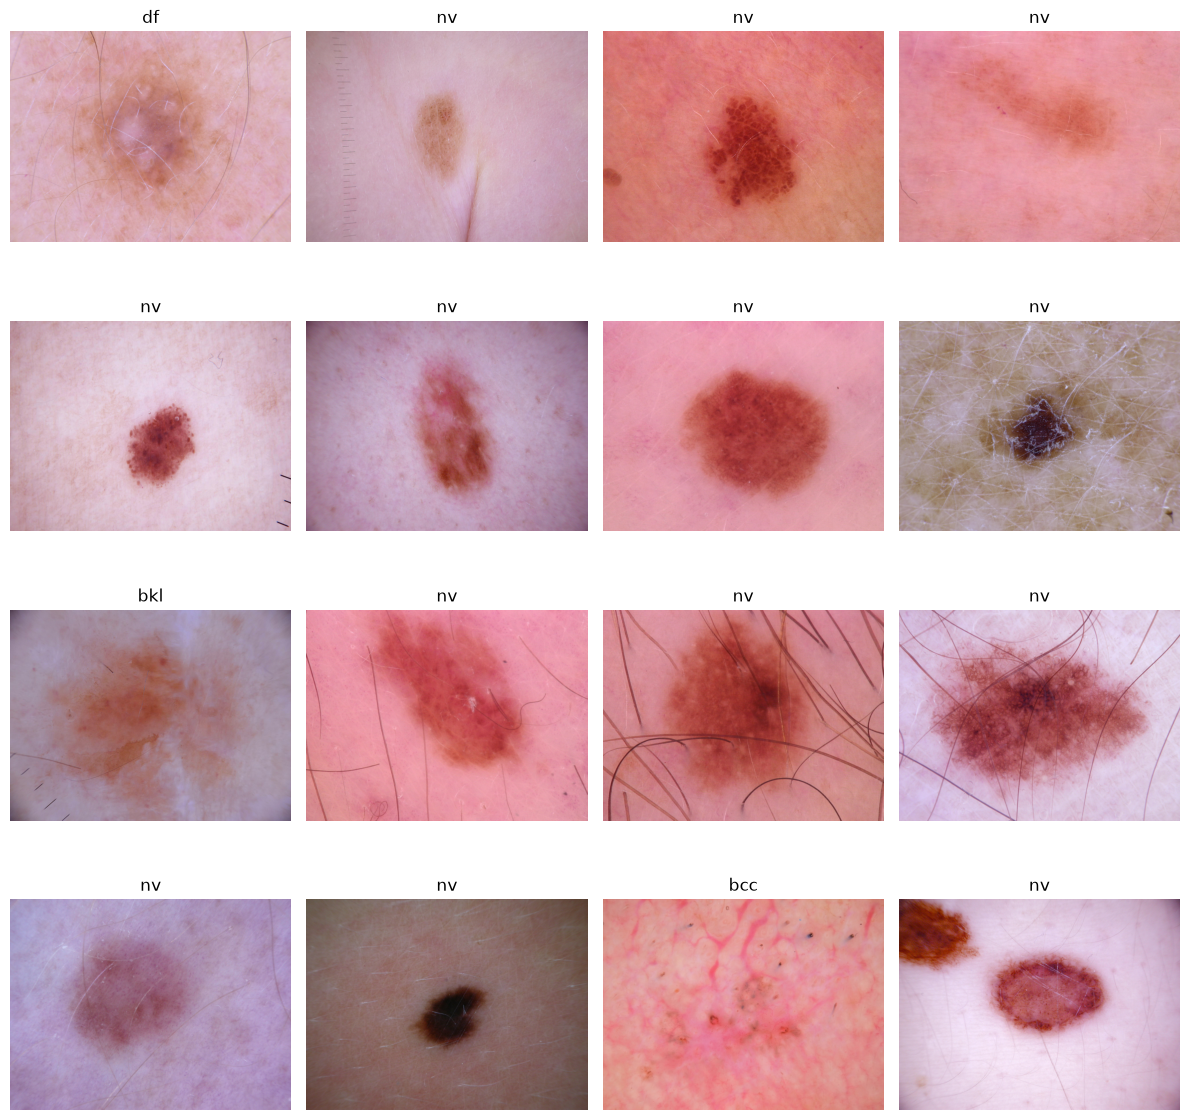

In [16]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1, 2, 0))
    ax.set_title(INDEX_TO_CLASS[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\nBatch size:", BATCH_SIZE)

print("\nTrain dataset:", len(train_loader.dataset))
print("Validation dataset:", len(val_loader.dataset))
print("Test dataset:", len(test_loader.dataset))

Train batches: 251
Validation batches: 32
Test batches: 32

Batch size: 32

Train dataset: 8011
Validation dataset: 1002
Test dataset: 1002


In [18]:
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))
test_images, test_labels = next(iter(test_loader))

print("Train:", train_images.shape, train_labels.shape)
print("Validation:", val_images.shape, val_labels.shape)
print("Test:", test_images.shape, test_labels.shape)

Train: torch.Size([32, 3, 450, 600]) torch.Size([32])
Validation: torch.Size([32, 3, 450, 600]) torch.Size([32])
Test: torch.Size([32, 3, 450, 600]) torch.Size([32])


In [19]:
print("Minimum label:", train_labels.min().item())
print("Maximum label:", train_labels.max().item())

print("Unique labels in batch:", torch.unique(train_labels).tolist())

Minimum label: 0
Maximum label: 6
Unique labels in batch: [0, 1, 2, 4, 5, 6]


In [20]:
print(train_df.columns.tolist())

['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'diagnosis_name', 'split', 'dataset_split']


In [21]:
print(train_df["dx"].value_counts().sort_index())

dx
akiec     262
bcc       411
bkl       879
df         92
mel       890
nv       5363
vasc      114
Name: count, dtype: int64


In [22]:
print(CLASS_TO_INDEX)
print(INDEX_TO_CLASS)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
{0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}


In [23]:
resize_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [24]:
resized_train_dataset = SkinLesionDataset(
    dataframe=train_df,
    image_dir=IMAGE_DIR,
    transform=resize_transform
)

image, label = resized_train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", INDEX_TO_CLASS[label])

Image shape: torch.Size([3, 224, 224])
Label: 2
Class: bkl


In [25]:
normalize_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
normalized_train_dataset = SkinLesionDataset(
    dataframe=train_df,
    image_dir=IMAGE_DIR,
    transform=normalize_transform
)

image, label = normalized_train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", INDEX_TO_CLASS[label])
print("Minimum value:", image.min().item())
print("Maximum value:", image.max().item())

Image shape: torch.Size([3, 224, 224])
Label: 2
Class: bkl
Minimum value: -1.160364031791687
Maximum value: 2.5877127647399902


In [27]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [28]:
augmented_train_dataset = SkinLesionDataset(
    dataframe=train_df,
    image_dir=IMAGE_DIR,
    transform=train_transform
)

In [29]:
image1, label1 = augmented_train_dataset[0]
image2, label2 = augmented_train_dataset[0]

print("Image 1 shape:", image1.shape)
print("Image 2 shape:", image2.shape)
print("Same label:", label1 == label2)

Image 1 shape: torch.Size([3, 224, 224])
Image 2 shape: torch.Size([3, 224, 224])
Same label: True


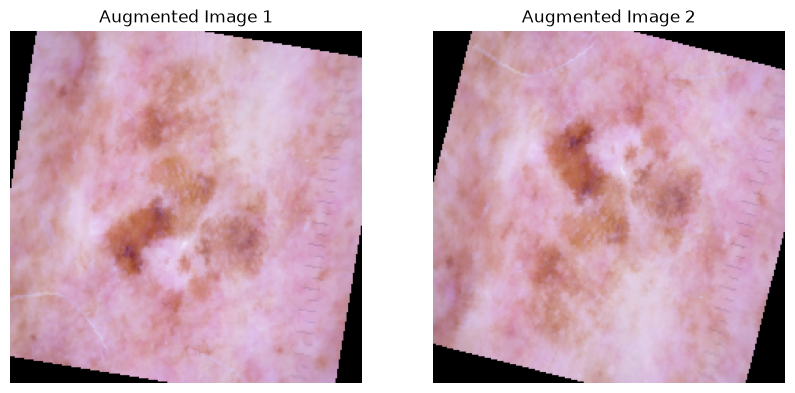

In [30]:
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

display_image1 = image1 * std + mean
display_image2 = image2 * std + mean

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(display_image1.permute(1, 2, 0).clamp(0, 1))
plt.title("Augmented Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_image2.permute(1, 2, 0).clamp(0, 1))
plt.title("Augmented Image 2")
plt.axis("off")

plt.show()

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [32]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [33]:
train_dataset = SkinLesionDataset(
    dataframe=train_df,
    image_dir=IMAGE_DIR,
    transform=train_transform
)

val_dataset = SkinLesionDataset(
    dataframe=val_df,
    image_dir=IMAGE_DIR,
    transform=val_test_transform
)

test_dataset = SkinLesionDataset(
    dataframe=test_df,
    image_dir=IMAGE_DIR,
    transform=val_test_transform
)

In [34]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [35]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image minimum:", images.min().item())
print("Image maximum:", images.max().item())
print("First 10 labels:", labels[:10])


Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image minimum: -2.1179039478302
Image maximum: 2.6225709915161133
First 10 labels: tensor([4, 5, 2, 5, 5, 5, 5, 1, 1, 5])
